# Week 7 Capstone: validated exploitation round

Week 7 contains eight exact, dimensionally valid Week 6 query/output pairs. This notebook reconciles the exact Week 3–4 pairs recovered from the later Week 9 record, appends the Week 6 returns, uses all 215 verified observations, leaves only the unavailable Week 5 return explicit, and generates reproducible exploitation-focused proposals.

## Errors found and corrected

1. Google Drive archives and every `/content/...` path are unavailable locally.
2. The inherited Week 6 archive is not in the repository and belongs to the previously corrupted lineage.
3. `allow_pickle=True` accepted object arrays, after which regex attempted to guess numbers from string representations. Scientific observations must never be reconstructed this way.
4. Malformed rows were silently dropped and outputs reindexed, potentially pairing the wrong `X` and `y`. Strict validation now fails instead.
5. EDA and best-point calculations were repeated many times, including duplicate charts and an empty cell.
6. Raw best/mean values from unrelated objective scales were compared in shared bar/line charts; within-function percentiles are used instead.
7. Inputs already live in `[0,1]`; fitting a `StandardScaler` and searching in unscaled space added unnecessary transformation risk.
8. Global random state made proposals order-dependent and rounded duplicates were not checked.
9. F5 was hard-coded to `[0,0,0,0]` despite an exploitation strategy; it now searches locally near the verified best.
10. GP diagnostics were discarded and the summary falsely marked inherited data confirmed. Kernels, uncertainty, UCB, distance, candidate source, and evidence status are reported.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}; METHOD={i:('Local exploitation' if i==5 else 'GP-UCB exploitation') for i in FUNCTIONS}; KAPPA={i:2. for i in FUNCTIONS if i!=5}
EARLY_QUERIES={1:[[.375440,.950714],[.536429,.835362],[.614168,.334143],[.872626,.321598]],2:[[.375440,.950714],[.978752,.932731],[.000006,.334143],[.197553,.808683]],3:[[.444444,.666666,.333333],[.657452,.998464,.817253],[.670026,.057881,.658241],[.650132,.218327,.110542]],4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202],[.394519,.361122,.256803,.461856],[.715715,.504442,.275065,.552962]],5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260],[.255842,.841692,.888985,.860266],[0.,0.,0.,0.]],6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321],[.495070,.097152,.672921,.000007,.351268],[.973181,.022807,.714484,.145453,.974790]],7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324],[.143585,.302559,.571101,.194533,.395561,.815792],[.045103,.016167,.773003,.156031,.147073,.616114]],8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846],[.088894,.525132,.030986,.992538,.870819,.217060,.011239,.447691],[.356502,.157574,.172997,.610561,.106477,.260297,.411421,.904740]]}
EARLY_OUTPUTS={1:[-1.560646704467778e-117,1.674933466363685e-36,-1.0755942664604116e-32,-2.4666412561217706e-107],2:[-.03182956281754251,.022666631114895516,.04868370128566149,.038774938576018964],3:[-.04090761844901528,-.08987474979637637,-.18323876643005035,-.08251349582236739],4:[-8.727516493155957,-31.73535839431216,-1.9810750402526334,-9.312811809021998],5:[1088.8535114737463,1035.6341457754475,1035.6647479285914,163.1225],6:[-1.1520351120911565,-.8782405650300305,-1.339542402620705,-2.4375082517089726],7:[1.0510148516295004,.308765180253091,2.149905456773691,1.2087334449610816],8:[9.8157087929671,9.9399041910574,8.9636037557014,9.2540644925525]}
WEEK6_QUERIES={1:[.897714,.081699],2:[.555332,.360931],3:[.522231,.090709,.451742],4:[.713766,.198601,.014095,.068347],5:[.754614,.504566,.432986,.307039],6:[.824244,.022732,.960907,.041715,.897560],7:[.052337,.910075,.727790,.075231,.386516,.492629],8:[.110992,.462977,.255313,.963757,.895383,.716713,.030436,.083412]}
WEEK6_OUTPUTS={1:7.651210225556565e-239,2:.22078072799826579,3:-.05739710166867316,4:-17.92630659900679,5:.9401160531598542,6:-2.5293691850310744,7:.19078262729854223,8:9.1386093133071}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_07').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}), got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: invalid counts.')
    if X.dtype==object or y.dtype==object: raise TypeError(f'F{fn}: object/pickle data is not accepted.')
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: non-finite data.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: inputs outside [0,1].')
def load_verified(fn):
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; a,b=folder/'initial_inputs.npy',folder/'initial_outputs.npy'
    X=np.asarray(np.load(a,allow_pickle=False),dtype=float); y=np.asarray(np.load(b,allow_pickle=False),dtype=float).reshape(-1); validate(fn,X,y)
    for q,v in zip(EARLY_QUERIES[fn],EARLY_OUTPUTS[fn]): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    q6=np.asarray(WEEK6_QUERIES[fn],float)
    if q6.shape!=(DIMS[fn],): raise ValueError(f'F{fn}: recorded Week 6 query has wrong dimension.')
    X=np.vstack((X,q6)); y=np.append(y,WEEK6_OUTPUTS[fn]); validate(fn,X,y); return X,y

## Function-by-function Week 6 return review

The newest observation is the independently recorded Week 6 return. Its improvement is measured against all other verified observations. Weeks 3–4 are reconciled from the later Week 9 record; the absent Week 5 return remains an explicit evidence gap.

In [3]:
def summarize(fn):
    X,y=load_verified(fn); previous=y[:-1]; best=int(np.argmax(y))
    return {'Function':f'F{fn}','Method':METHOD[fn],'Dimensions':DIMS[fn],'Verified observations':len(y),'Previous best':float(np.max(previous)),'Week 6 return':float(y[-1]),'Verified best':float(y[best]),'Week 6 improvement':float(np.max(y)-np.max(previous)),'Week 6 percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Recovered provenance':'Weeks 3–4 exact pairs recovered from Week 9 record','Evidence gap':'Week 5 return unavailable'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Method,Dimensions,Verified observations,Previous best,Week 6 return,Verified best,Week 6 improvement,Week 6 percentile,Best query,Best input,Recovered provenance,Evidence gap
0,F1,GP-UCB exploitation,2,15,7.710875e-16,7.651210e-239,7.710875e-16,0.0,42.857143,3,"[0.7310236309563586, 0.7329998764152272]",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
1,F2,GP-UCB exploitation,2,15,6.112052e-01,2.207807e-01,6.112052e-01,0.0,64.285714,10,"[0.7026365569244406, 0.9265641975455574]",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
2,F3,GP-UCB exploitation,3,20,-3.483531e-02,-5.739710e-02,-3.483531e-02,0.0,68.421053,4,"[0.49258141463713434, 0.6115931882759961, 0.34...",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
3,F4,GP-UCB exploitation,4,35,-1.981075e+00,-1.792631e+01,-1.981075e+00,0.0,32.352941,33,"[0.394519, 0.361122, 0.256803, 0.461856]",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
4,F5,Local exploitation,4,25,1.088860e+03,9.401161e-01,1.088860e+03,0.0,4.166667,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
5,F6,GP-UCB exploitation,5,25,-7.142649e-01,-2.529369e+00,-7.142649e-01,0.0,4.166667,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
6,F7,GP-UCB exploitation,6,35,2.149905e+00,1.907826e-01,2.149905e+00,0.0,55.882353,33,"[0.143585, 0.302559, 0.571101, 0.194533, 0.395...",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable
7,F8,GP-UCB exploitation,8,45,9.939904e+00,9.138609e+00,9.939904e+00,0.0,84.090909,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...",Weeks 3–4 exact pairs recovered from Week 9 re...,Week 5 return unavailable


In [4]:
for r in performance.to_dict('records'):
    status='IMPROVED' if r['Week 6 improvement']>0 else 'NO NEW BEST'
    print(f"{r['Function']} — {r['Method']} — {status}")
    print(f"  verified observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  previous={r['Previous best']:.12g}, Week 6 return={r['Week 6 return']:.12g}, best={r['Verified best']:.12g}")
    print(f"  provenance: {r['Recovered provenance']}")
    print(f"  evidence gap: {r['Evidence gap']}")

F1 — GP-UCB exploitation — NO NEW BEST
  verified observations=15, dimensions=2
  previous=7.7108751145e-16, Week 6 return=7.65121022556e-239, best=7.7108751145e-16
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
  evidence gap: Week 5 return unavailable
F2 — GP-UCB exploitation — NO NEW BEST
  verified observations=15, dimensions=2
  previous=0.611205215761, Week 6 return=0.220780727998, best=0.611205215761
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
  evidence gap: Week 5 return unavailable
F3 — GP-UCB exploitation — NO NEW BEST
  verified observations=20, dimensions=3
  previous=-0.0348353133501, Week 6 return=-0.0573971016687, best=-0.0348353133501
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
  evidence gap: Week 5 return unavailable
F4 — GP-UCB exploitation — NO NEW BEST
  verified observations=35, dimensions=4
  previous=-1.98107504025, Week 6 return=-17.926306599, best=-1.98107504025
  provenance: Weeks 3–4 exact pairs re

## Exploitation-focused Week 7 proposals

GP functions evaluate 5,000 global and 5,000 local candidates with UCB κ=2. F5 performs bounded local search. Proposals are checked after six-decimal rounding.

In [5]:
def distinct(points,X,scores):
    for idx in np.argsort(scores)[::-1]:
        q=np.round(points[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)): return idx,q
    raise RuntimeError('No distinct proposal.')
def local_manual(X,y,rng,n=5000,scale=.05):
    centre=X[int(np.argmax(y))]; points=np.clip(centre+rng.normal(0,scale,(n,X.shape[1])),0,1); scores=-np.linalg.norm(points-centre,axis=1); idx,q=distinct(points,X,scores); return {'query':q,'kernel':'Manual local exploitation','mean':np.nan,'std':np.nan,'ucb':np.nan,'source':'local'}
def gp_query(X,y,rng,kappa=2.):
    d=X.shape[1]; centre=X[int(np.argmax(y))]; points=np.vstack((rng.uniform(0,1,(5000,d)),np.clip(centre+rng.normal(0,.06,(5000,d)),0,1)))
    kernel=ConstantKernel(1.,(1e-3,1e3))*Matern(np.ones(d),(1e-2,1e2),nu=2.5)+WhiteKernel(1e-5,(1e-10,1e1)); gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    mean,std=gp.predict(points,return_std=True); ucb=mean+kappa*std; idx,q=distinct(points,X,ucb); return {'query':q,'kernel':str(gp.kernel_),'mean':float(mean[idx]),'std':float(std[idx]),'ucb':float(ucb[idx]),'source':'global' if idx<5000 else 'local'}

In [6]:
week7_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_verified(fn); rng=np.random.default_rng(700+fn); result=local_manual(X,y,rng) if fn==5 else gp_query(X,y,rng); q=result['query']; week7_queries[fn]=q
    rows.append({'Function':f'F{fn}','Method':METHOD[fn],'Candidate source':result['source'],'Proposed query':q.tolist(),'Fitted kernel':result['kernel'],'Predictive mean':result['mean'],'Predictive std':result['std'],'UCB score':result['ucb'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Method,Candidate source,Proposed query,Fitted kernel,Predictive mean,Predictive std,UCB score,Distance from best
0,F1,GP-UCB exploitation,global,"[0.297142, 0.511536]","1.1**2 * Matern(length_scale=[100, 0.0389], nu...",-0.000156,0.000968,0.001780,0.487134
1,F2,GP-UCB exploitation,global,"[0.688104, 0.280651]","0.952**2 * Matern(length_scale=[0.0453, 100], ...",0.605554,0.069273,0.744099,0.646077
2,F3,GP-UCB exploitation,global,"[0.080256, 0.695305, 2.1e-05]","1.78**2 * Matern(length_scale=[100, 100, 0.115...",-0.016251,0.071928,0.127604,0.541041
3,F4,GP-UCB exploitation,local,"[0.353952, 0.411807, 0.429262, 0.423195]","4.57**2 * Matern(length_scale=[1.96, 1.92, 1.9...",-1.164427,0.526906,-0.110615,0.188286
4,F5,Local exploitation,local,"[0.218201, 0.849622, 0.875389, 0.878722]",Manual local exploitation,NaN,NaN,NaN,0.007908
5,F6,GP-UCB exploitation,global,"[0.493191, 0.005354, 0.957465, 0.964121, 0.173...","1.41**2 * Matern(length_scale=[0.433, 1.17, 1....",-0.536281,0.349015,0.161749,0.463520
6,F7,GP-UCB exploitation,local,"[0.013511, 0.226133, 0.588863, 0.046016, 0.344...","1.11**2 * Matern(length_scale=[1.04, 0.486, 10...",2.316512,0.169154,2.654820,0.238242
7,F8,GP-UCB exploitation,local,"[0.024008, 0.05518, 0.185402, 0.042421, 1.0, 0...","6.97**2 * Matern(length_scale=[4.73, 7.34, 3.8...",9.946143,0.054432,10.055006,0.223406


## Complete Matplotlib diagnostics

Red diamonds mark the Week 6 return and gold stars the verified optimum. Feature panels are coloured by verified query order.

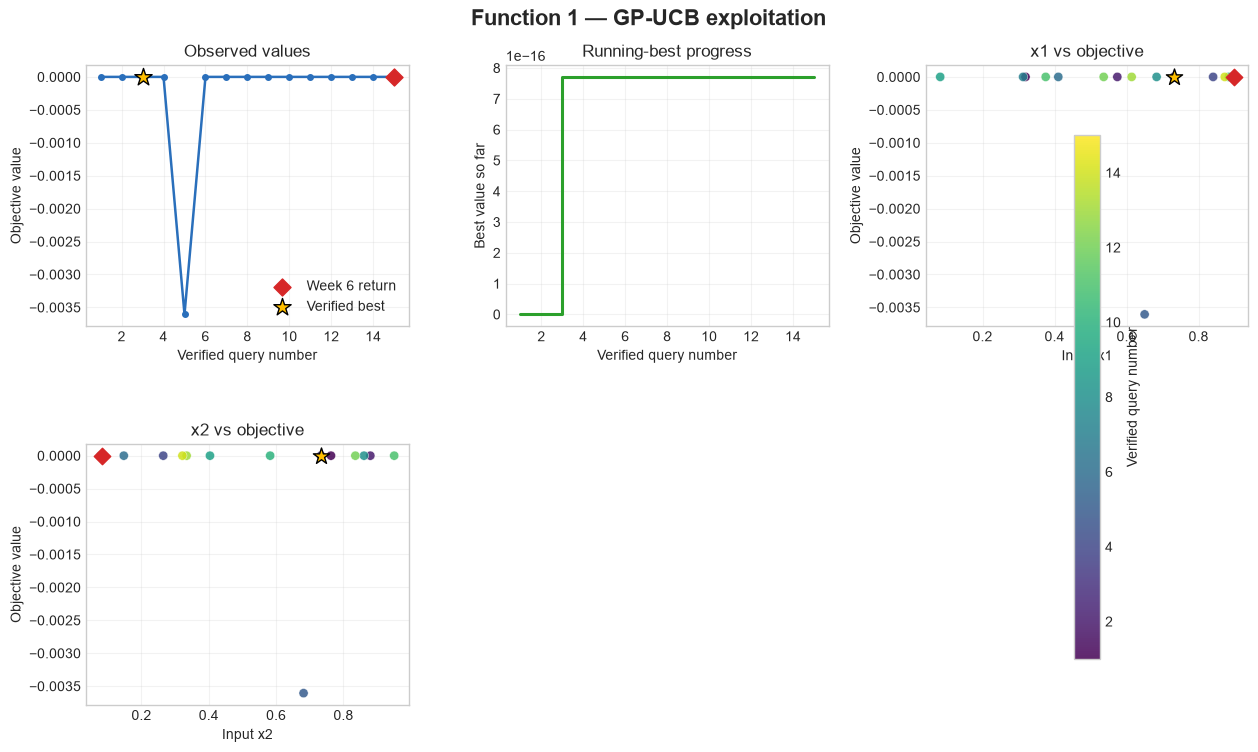

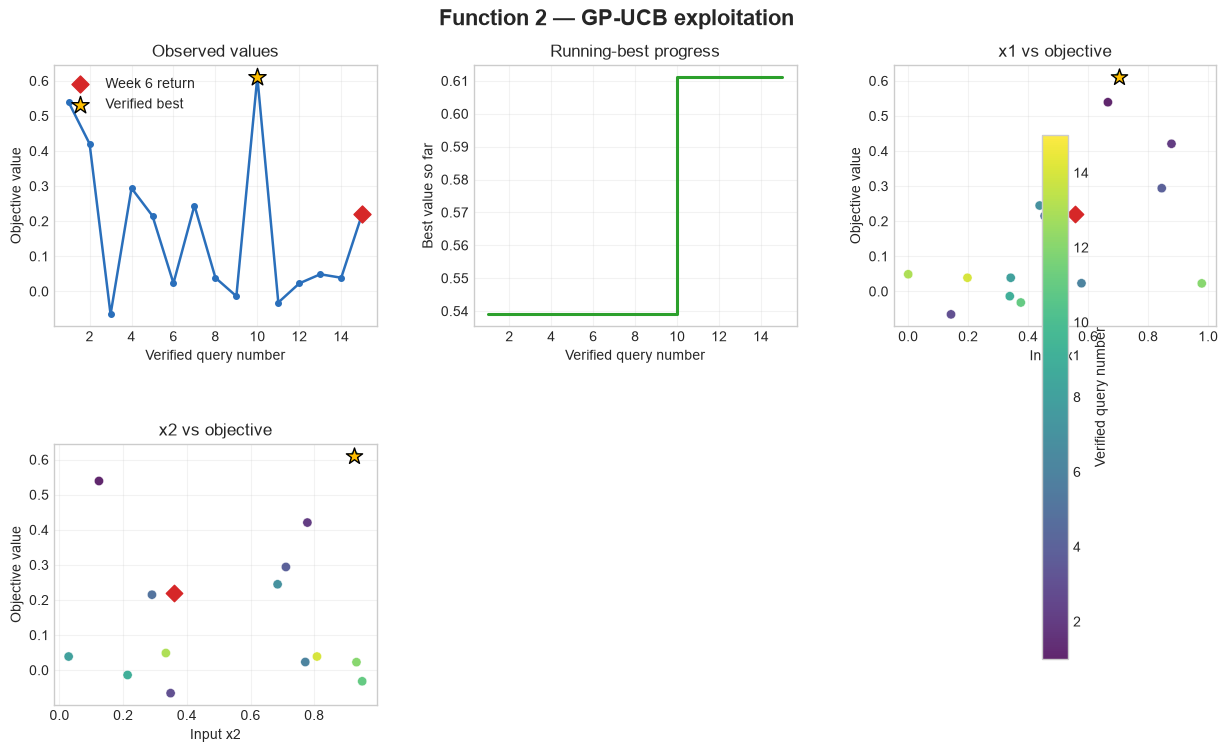

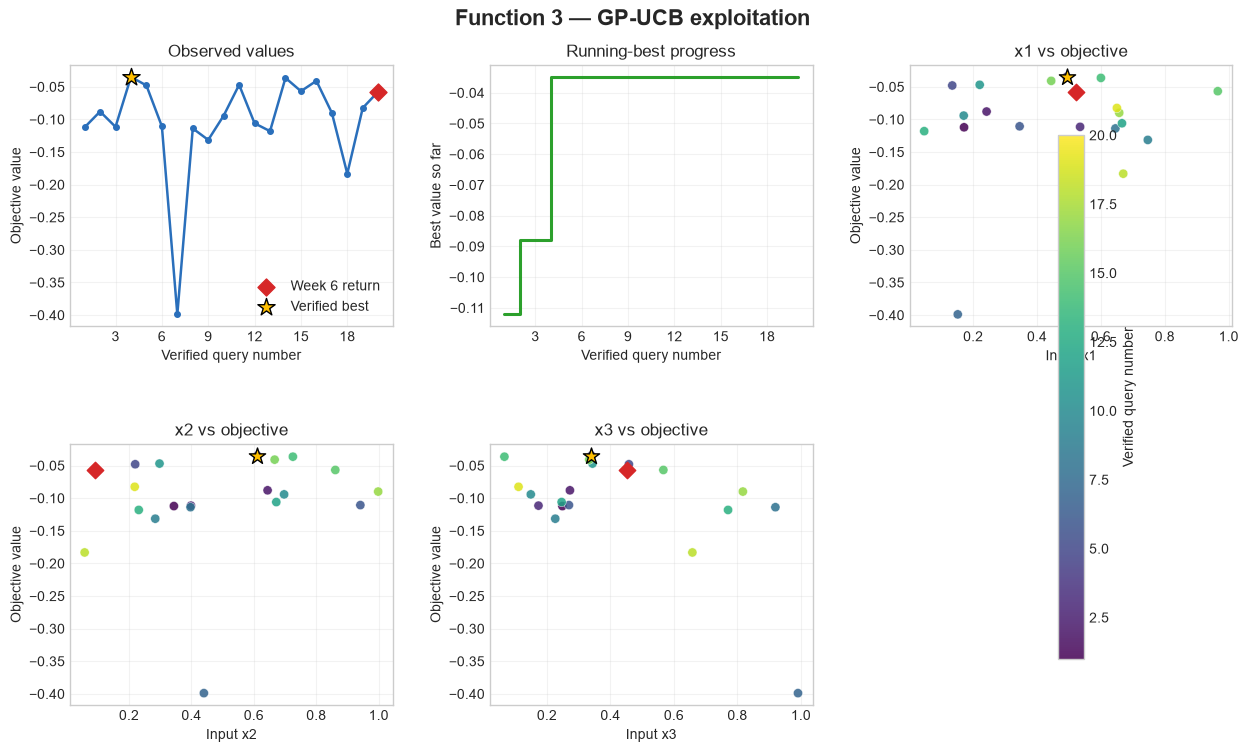

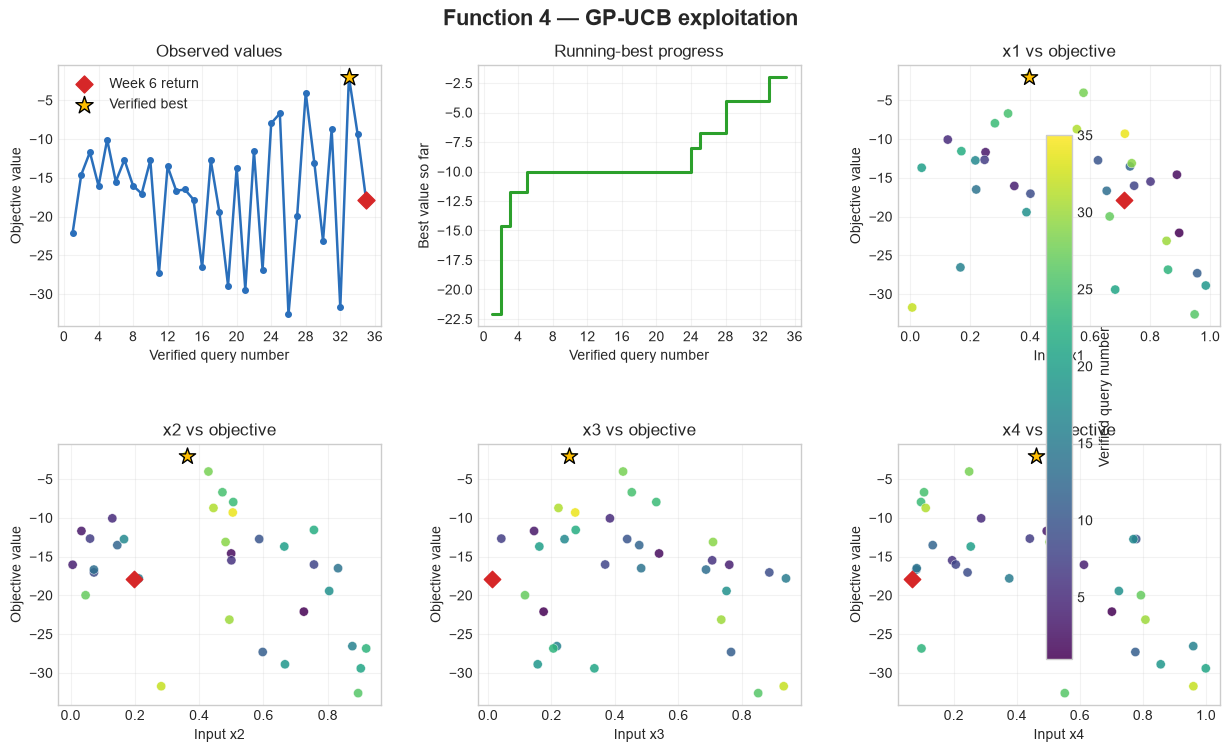

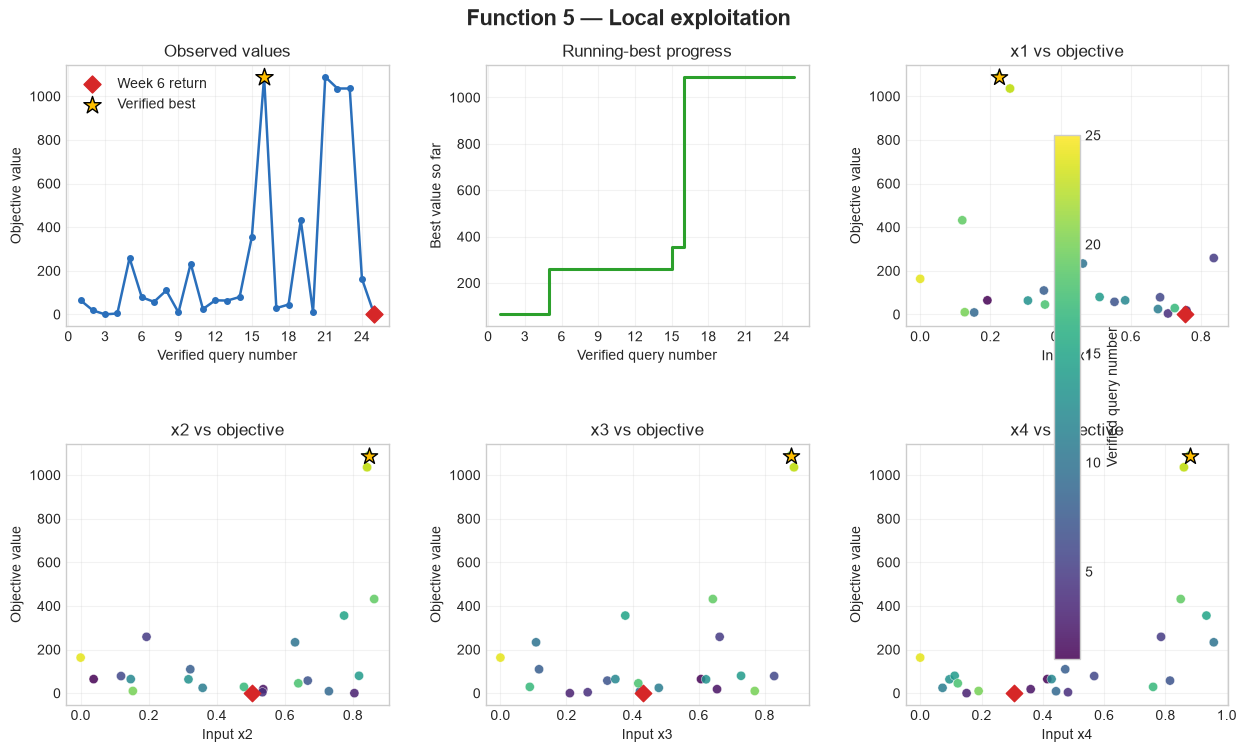

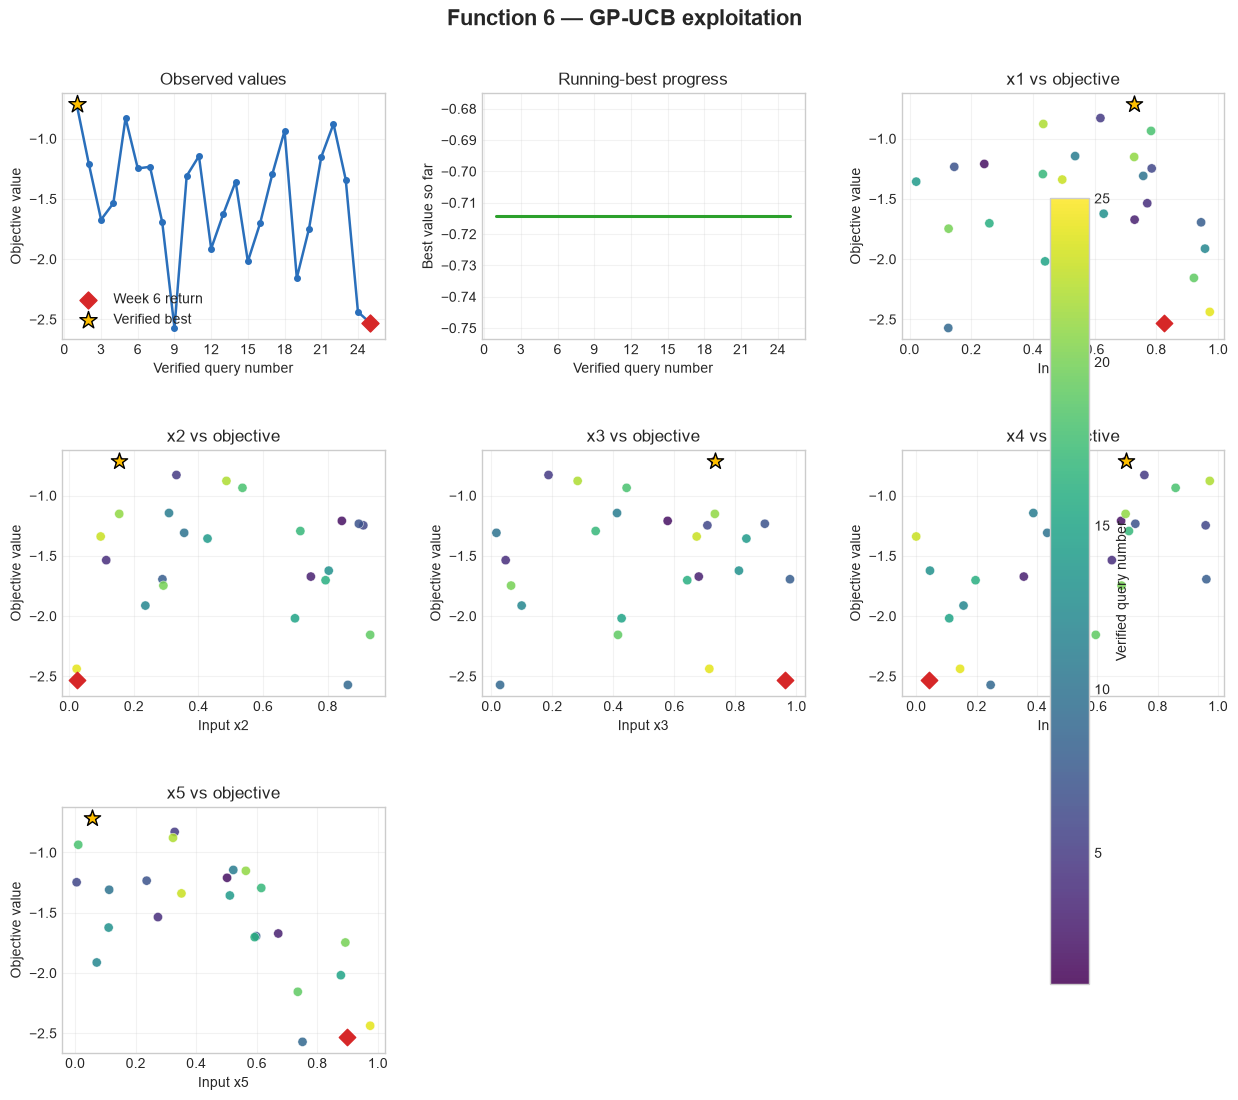

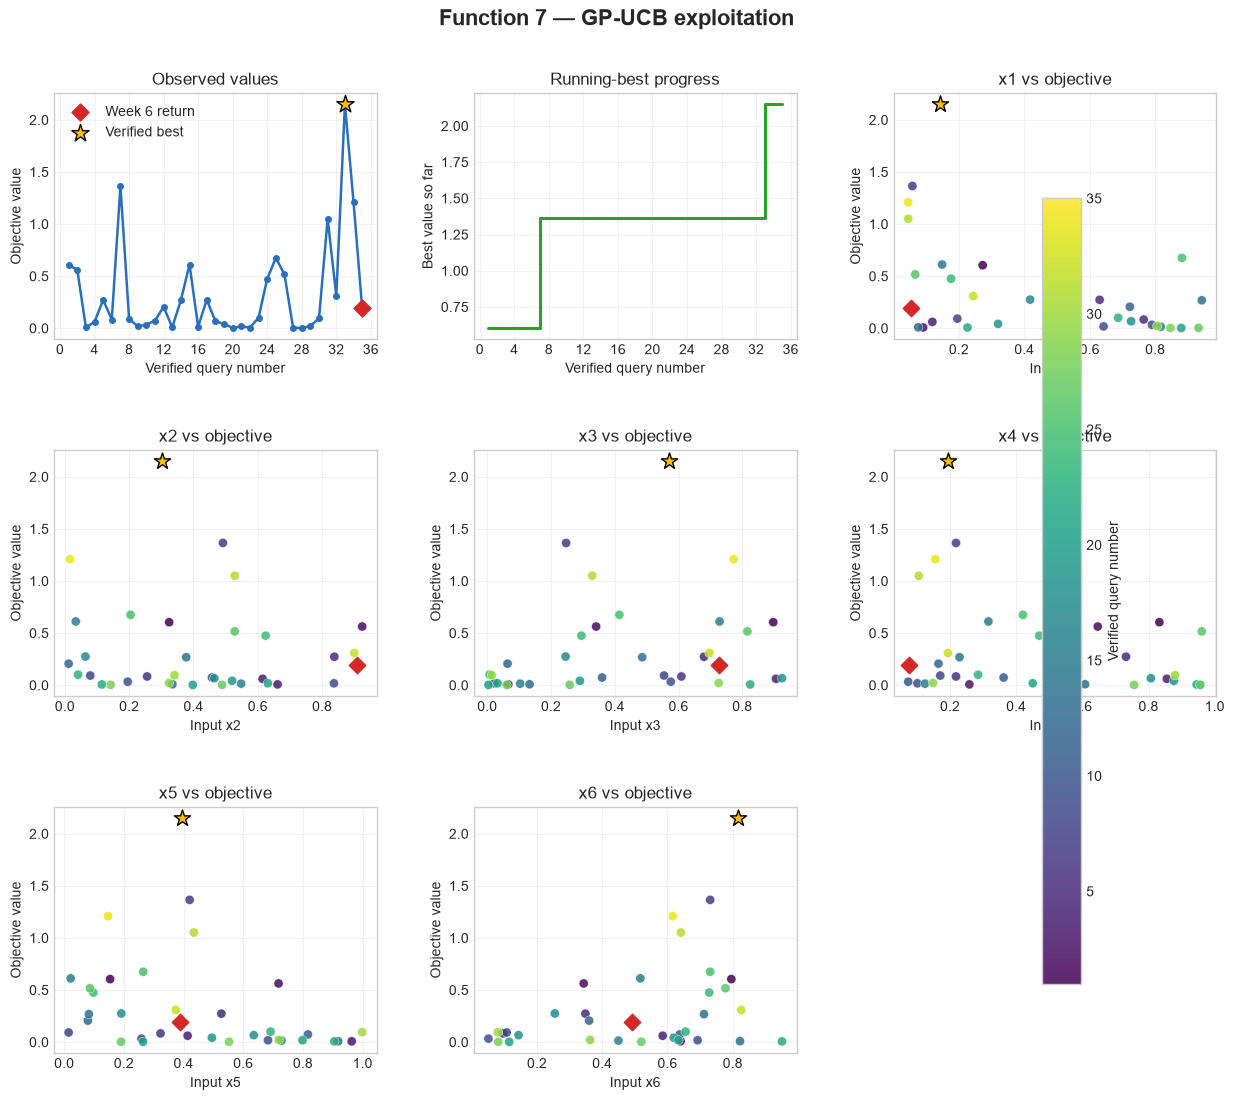

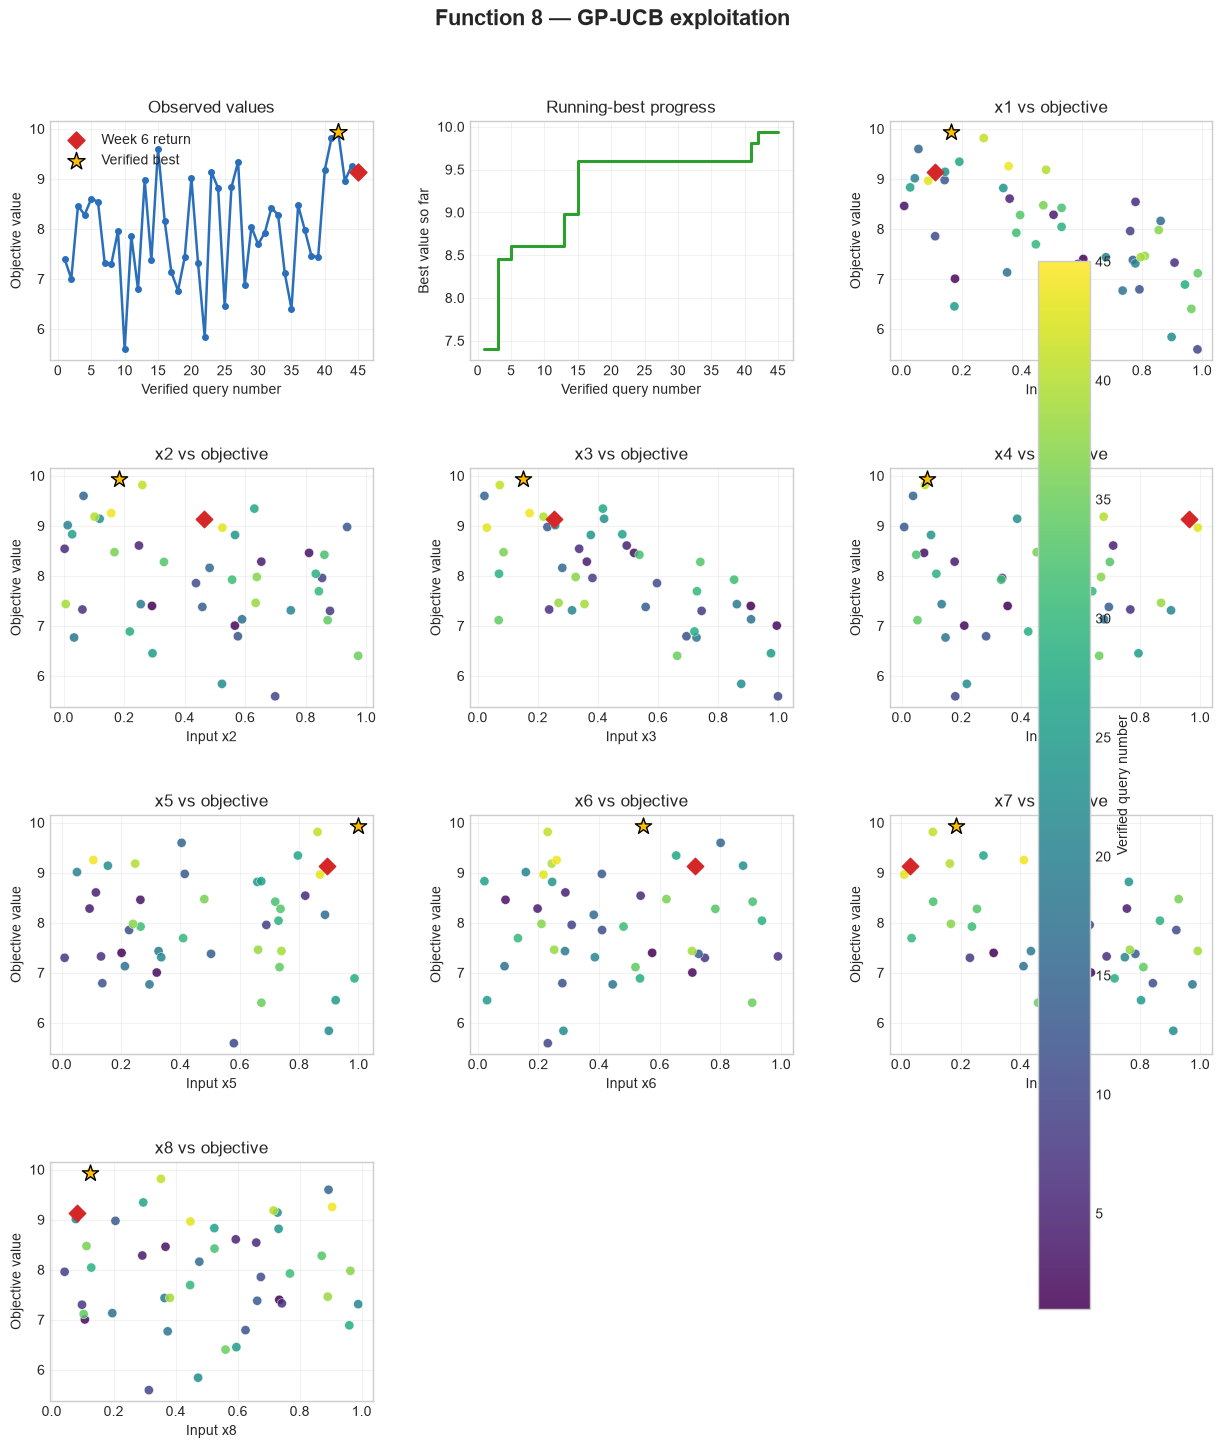

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_verified(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3; rows=math.ceil(panels/cols); fig,axes=plt.subplots(rows,cols,figsize=(15,4*rows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Week 6 return'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Verified best'); axes[0].set(xlabel='Verified query number',ylabel='Objective value',title='Observed values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Verified query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True)); colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]): colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[-1,col],y[-1],marker='D',color='#d62728',s=70,zorder=4); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Verified query number',shrink=.85); fig.suptitle(f'Function {fn} — {METHOD[fn]}',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

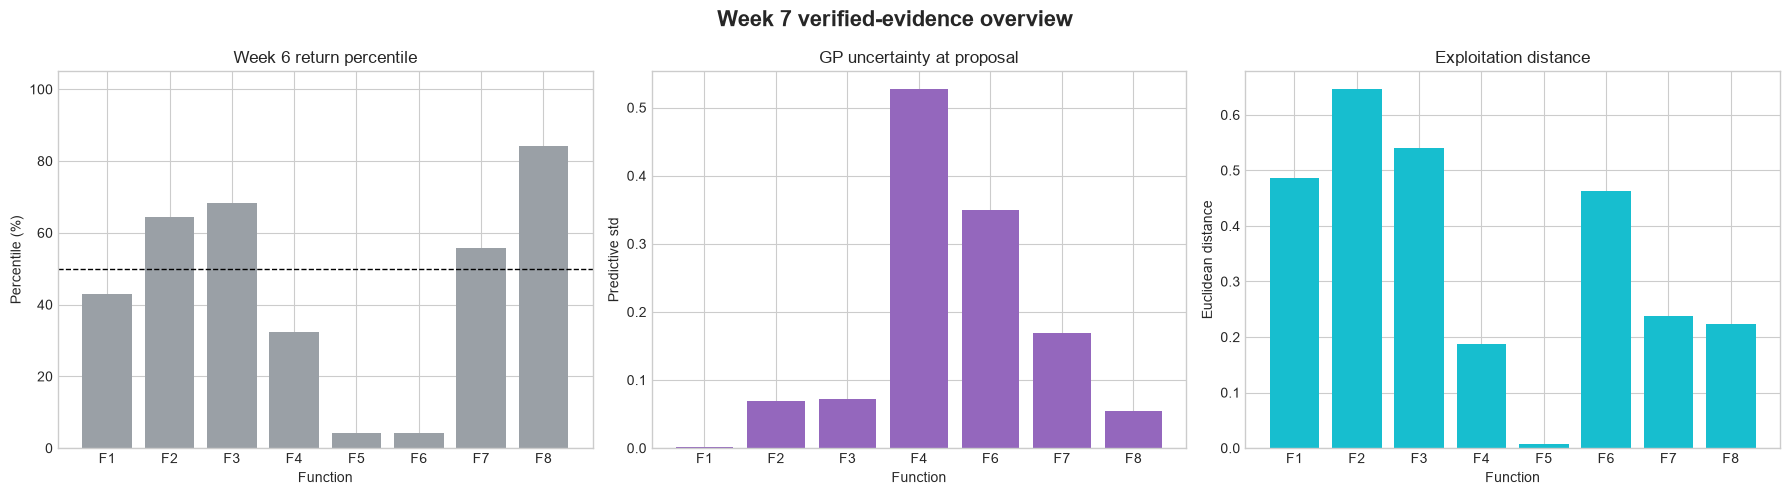

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Week 6 improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Week 6 percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1); axes[0].set(title='Week 6 return percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
gp=proposal_summary['Method'].eq('GP-UCB exploitation'); axes[1].bar(proposal_summary.loc[gp,'Function'],proposal_summary.loc[gp,'Predictive std'],color='#9467bd'); axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from best'],color='#17becf'); axes[2].set(title='Exploitation distance',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 7 verified-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:15,2:15,3:20,4:35,5:25,6:25,7:35,8:45}
for fn in FUNCTIONS:
    X,y=load_verified(fn); s=summarize(fn); q=week7_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],) and X.dtype!=object and y.dtype!=object
    assert np.allclose(X[-1],WEEK6_QUERIES[fn]) and np.isclose(y[-1],WEEK6_OUTPUTS[fn]); assert s['Best query']==int(np.argmax(y))+1 and s['Week 6 improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==215 and len(performance)==len(proposal_summary)==len(week7_queries)==8
assert performance['Recovered provenance'].str.contains('recovered from Week 9').all()
assert performance['Evidence gap'].eq('Week 5 return unavailable').all()
print('All Week 7 reconciled-data, provenance, performance, exploitation-proposal, and plotting checks passed.')

All Week 7 reconciled-data, provenance, performance, exploitation-proposal, and plotting checks passed.
